In [1]:
#import libraries

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
#load data
NOAA_SFO_df = pd.read_parquet(
    "../Data_Preprocessing/data/NOAA_SFO_2022_2026_cleaned.parquet"
)

NOAA_SFO_df.head()

,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,ELEVATION,temperature,...,wind_speed,wind_direction,sea_level_pressure,station_level_pressure,wet_bulb_temperature,ceiling_height,altimeter,sky_condition_baseht,sky_cover_summation_baseht_1,precipitation
0,2022-01-01 00:00:00,2022,1,1,0,0,37.6197,-122.3656,3.0,11.7,...,7.7,290.0,1012.4,1009.4,8.2,22000.0,NaN,800.0,NaN,NaN
1,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,3.0,10.6,...,7.2,300.0,1012.8,1012.3,7.9,22000.0,1012.9,610.0,610.0,0.0
2,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,3.0,10.0,...,5.1,300.0,1013.3,1012.6,7.4,22000.0,1013.2,579.0,579.0,0.0
3,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,3.0,9.4,...,5.1,290.0,1014.0,1013.6,7.1,22000.0,1014.2,NaN,NaN,0.0
4,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,3.0,9.4,...,5.1,310.0,1014.6,1014.0,7.3,22000.0,1014.6,914.0,914.0,0.0


**Distribution of data accross the years were not the same. System was recording more entries in 2026. Filter for cases where temperature data is measured to get more even distribution**

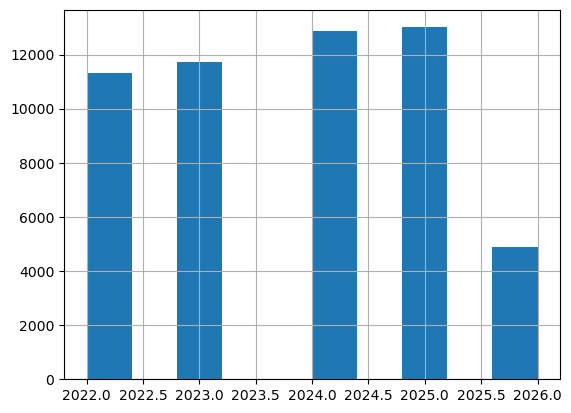

In [3]:
#check
plt.hist(NOAA_SFO_df["Year"])
plt.grid()
plt.show()



In [4]:
#remove cases where temp is null
NOAA_SFO_df = NOAA_SFO_df.dropna(subset=["temperature"])

NOAA_SFO_df.shape

(53785, 23)

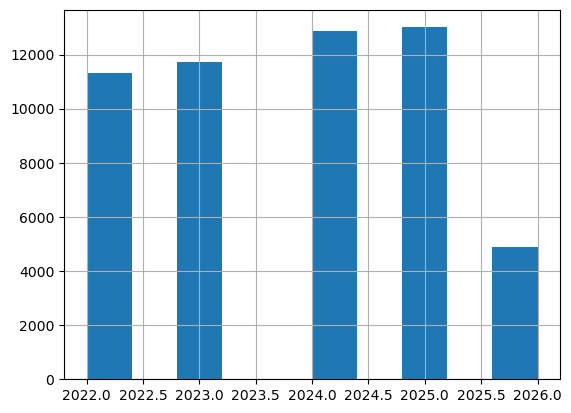

In [5]:
#check
plt.hist(NOAA_SFO_df["Year"])
plt.grid()
plt.show()

**Split training and test data for EDA purposes**
60/20/20 training/test/validation split. it is crucial we do not perform EDA on test and validation dataset

In [6]:
#First split:
# train = oldest 60%
# temp = most recent 40%
NOAA_train_df, NOAA_temp_df = train_test_split(
    NOAA_SFO_df,
    test_size=0.40,
    shuffle=False
)

# Second split:
# test = older half of temp, so subsequent 20%
# validation = newer half of temp, so most recent 20%
NOAA_test_df, NOAA_val_df = train_test_split(
    NOAA_temp_df,
    test_size=0.50,
    shuffle=False
)

# Check shapes
print(f"Training shape: {NOAA_train_df.shape}")
print(f"Test shape: {NOAA_test_df.shape}")
print(f"Validation shape: {NOAA_val_df.shape}")

Training shape: (32271, 23)
Test shape: (10757, 23)
Validation shape: (10757, 23)


In [7]:
#Verify split by confirming date 

print("Training date range:")
print(NOAA_train_df["DATE"].min(), "to", NOAA_train_df["DATE"].max())

print("\nTest date range:")
print(NOAA_test_df["DATE"].min(), "to", NOAA_test_df["DATE"].max())

print("\nValidation date range:")
print(NOAA_val_df["DATE"].min(), "to", NOAA_val_df["DATE"].max())

Training date range:
2022-01-01 00:00:00 to 2024-09-20 01:56:00

Test date range:
2024-09-20 02:39:00 to 2025-07-20 19:56:00

Validation date range:
2025-07-20 20:56:00 to 2026-06-09 16:56:00


**Perform EDA**

Describe float features

In [8]:
feature_cols = [
    "LATITUDE",
    "LONGITUDE",
    "ELEVATION",
    "temperature",
    "dew_point_temperature",
    "wind_direction",
    "wind_speed",
    "wind_gust",
    "precipitation",
    "relative_humidity",
    "visibility",
    "sea_level_pressure",
    "station_level_pressure",
    "ceiling_height",
    "altimeter"
]

feature_cols = [col for col in feature_cols if col in NOAA_train_df.columns]

display(NOAA_train_df[feature_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
LATITUDE,32271.0,37.619700,3.318286e-12,37.6197,37.6197,37.6197,37.6197,37.6197
LONGITUDE,32271.0,-122.365600,4.131159e-11,-122.3656,-122.3656,-122.3656,-122.3656,-122.3656
ELEVATION,32271.0,3.000000,0.000000e+00,3.0000,3.0000,3.0000,3.0000,3.0000
temperature,32271.0,14.397756,3.926582e+00,2.2000,11.7000,13.9000,16.7000,36.7000
dew_point_temperature,32271.0,9.385377,3.500049e+00,-8.9000,7.2000,10.0000,12.2000,20.0000
wind_direction,32265.0,310.833690,2.336927e+02,10.0000,220.0000,280.0000,300.0000,999.0000
wind_speed,32265.0,4.838367,3.162469e+00,0.0000,2.6000,4.6000,6.7000,22.1000
precipitation,24234.0,0.077474,5.033127e-01,0.0000,0.0000,0.0000,0.0000,14.0000
relative_humidity,32271.0,73.635803,1.384553e+01,15.0000,65.0000,76.0000,83.0000,100.0000
visibility,32271.0,15.455559,2.385582e+00,0.0000,16.0930,16.0930,16.0930,16.0930


Distribution of float features

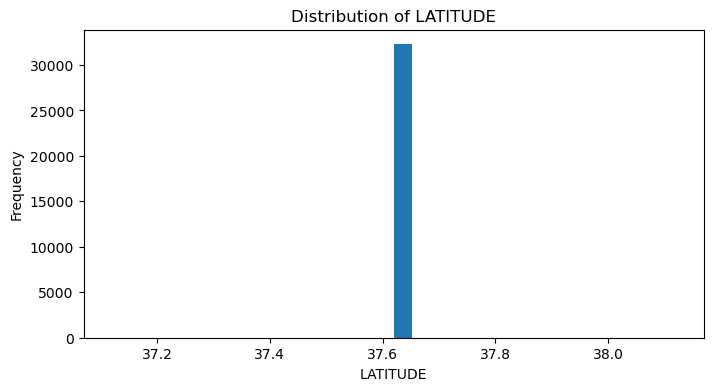

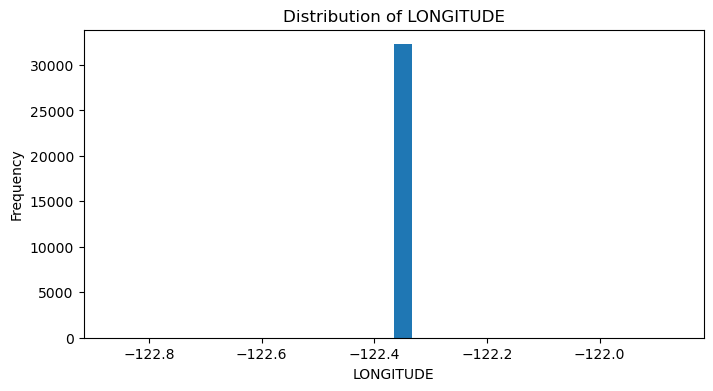

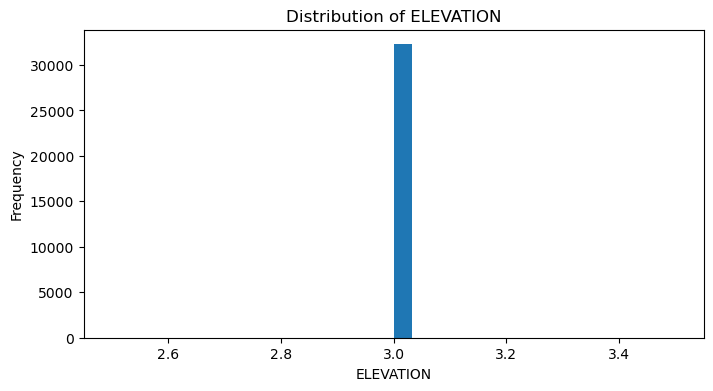

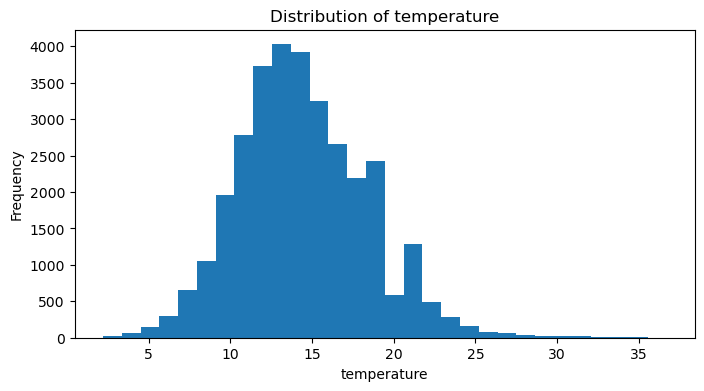

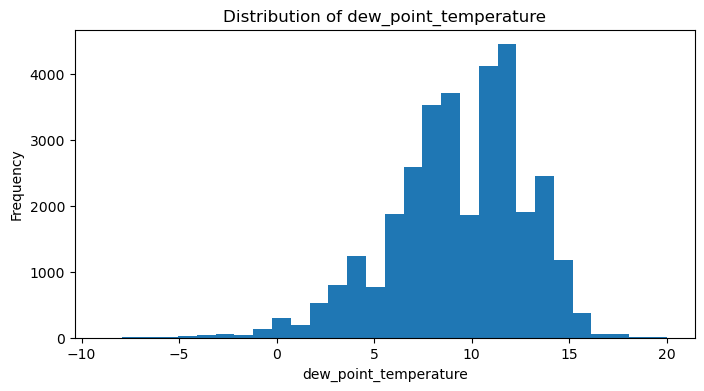

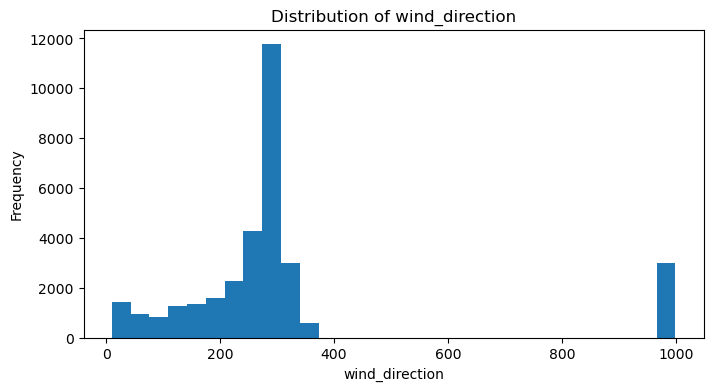

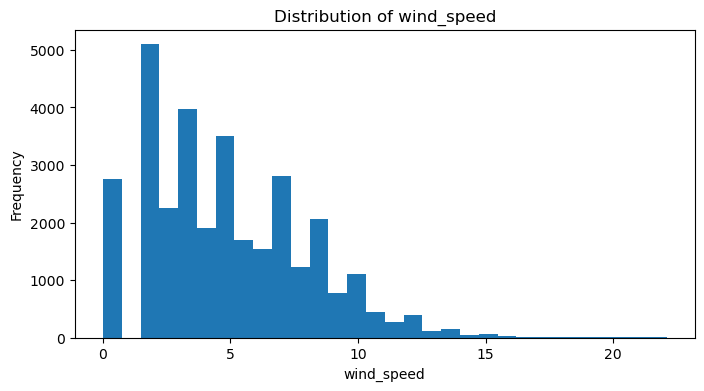

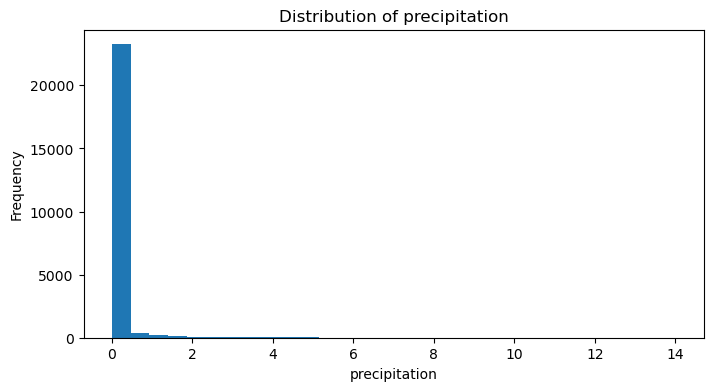

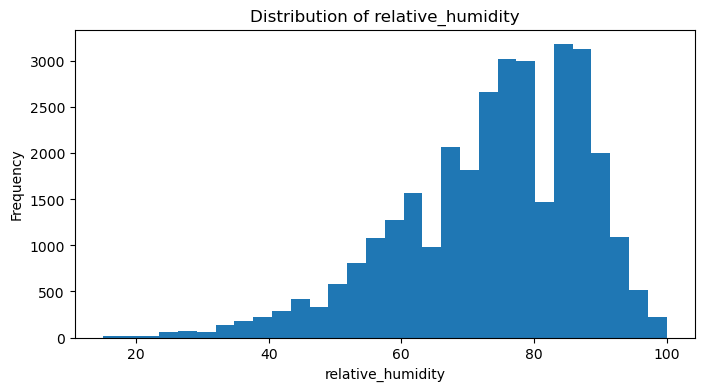

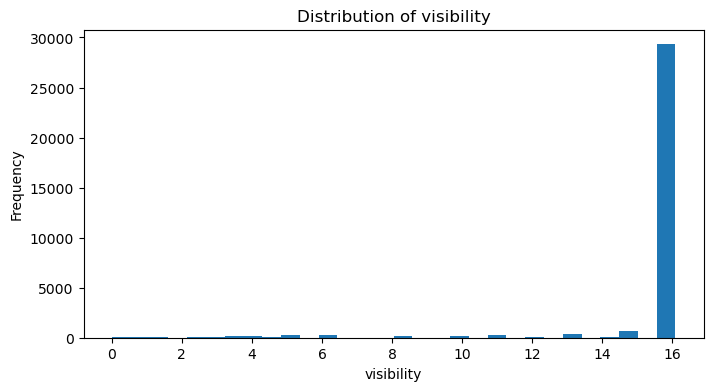

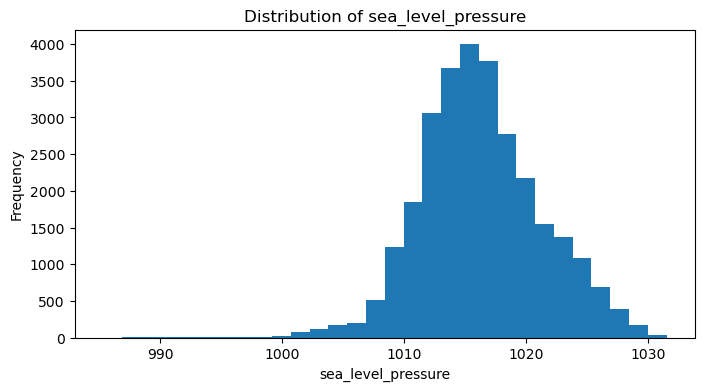

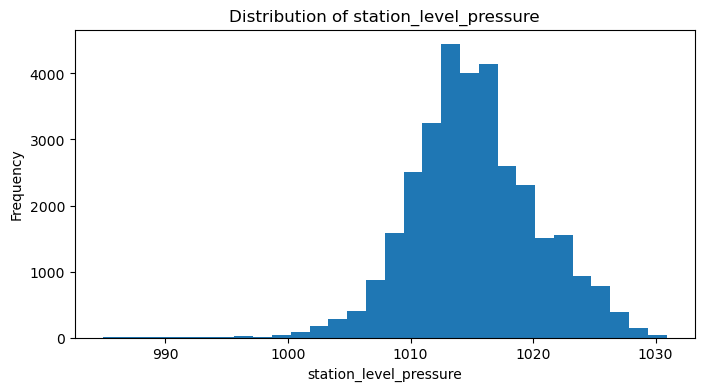

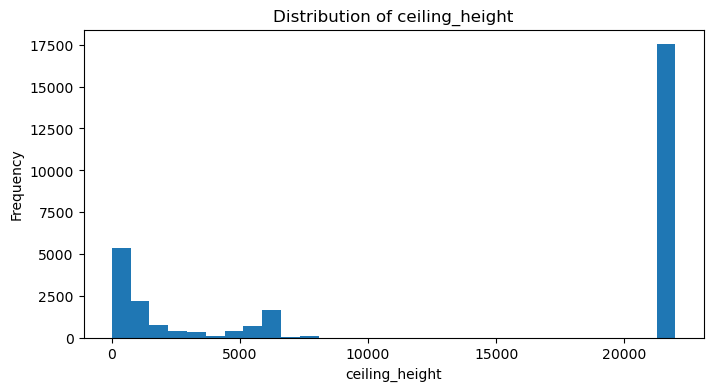

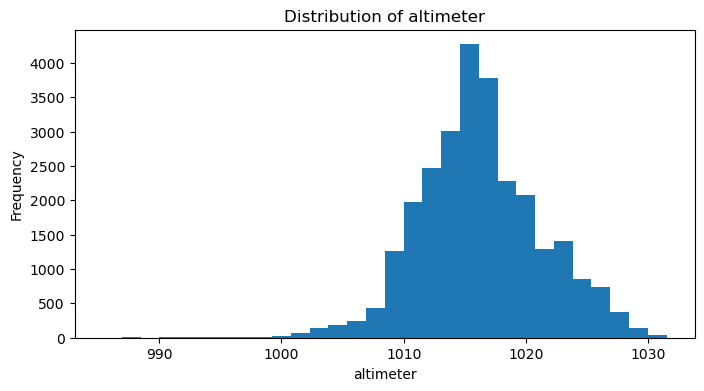

In [9]:
for col in feature_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(NOAA_train_df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()

Monthly trends

In [10]:
#Distribution plots of weather information

#create monthly trends
monthly_trend = [
    "temperature",
    "wind_speed",
    "visibility",
    "precipitation",
    "relative_humidity",
    "sea_level_pressure",
    "station_level_pressure",
    "altimeter"

]

# Create month/year bin
NOAA_train_df["Month_Year"] = NOAA_train_df["DATE"].dt.to_period("M")

# Calculate monthly average temperature
monthly_weather = NOAA_train_df.groupby("Month_Year")[monthly_trend].mean().reset_index()

# Convert Month_Year back to timestamp for plotting
monthly_weather["Month_Year"] = monthly_weather["Month_Year"].dt.to_timestamp()

Temperature Distribution


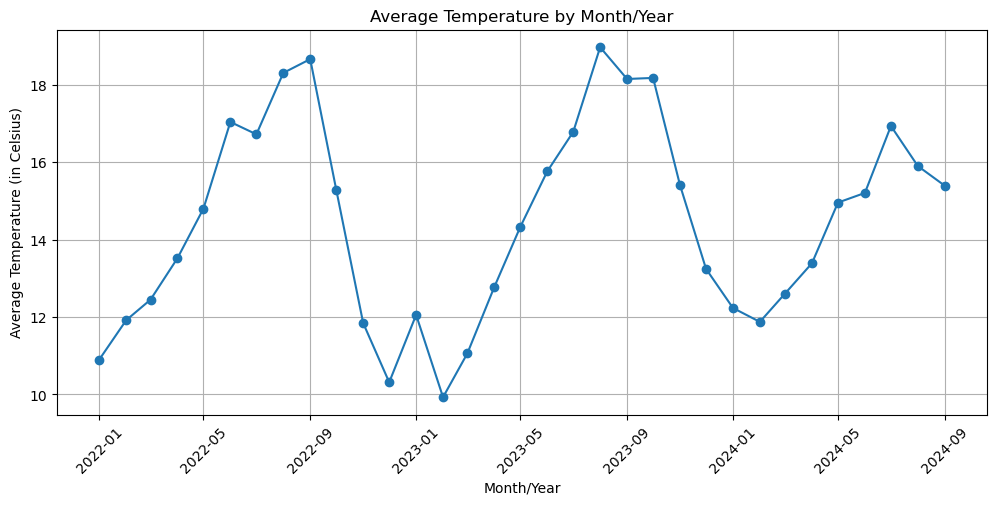

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_weather["Month_Year"], monthly_weather["temperature"], marker="o")

plt.xlabel("Month/Year")
plt.ylabel("Average Temperature (in Celsius)")
plt.title("Average Temperature by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Wind speed monthly

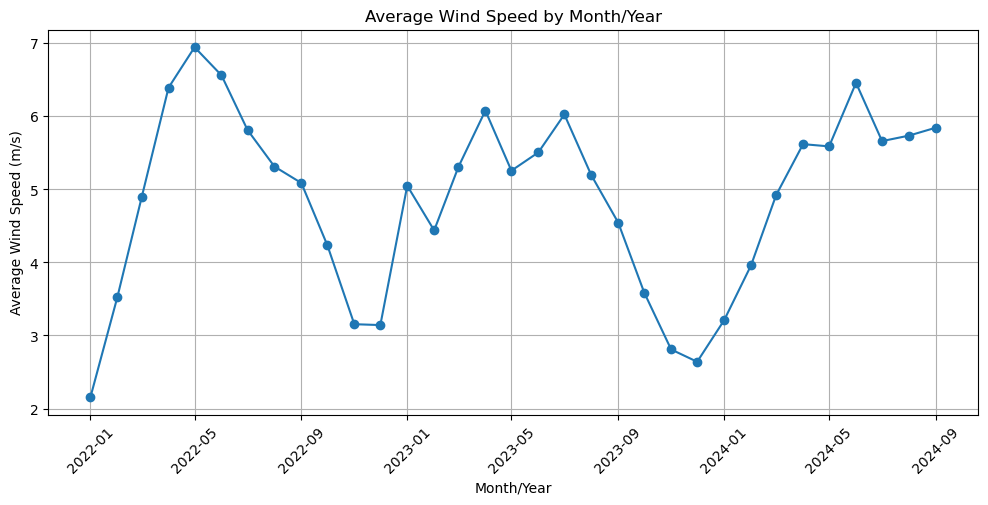

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_weather["Month_Year"], monthly_weather["wind_speed"], marker="o")

plt.xlabel("Month/Year")
plt.ylabel("Average Wind Speed (m/s)")
plt.title("Average Wind Speed by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Monthly visibility

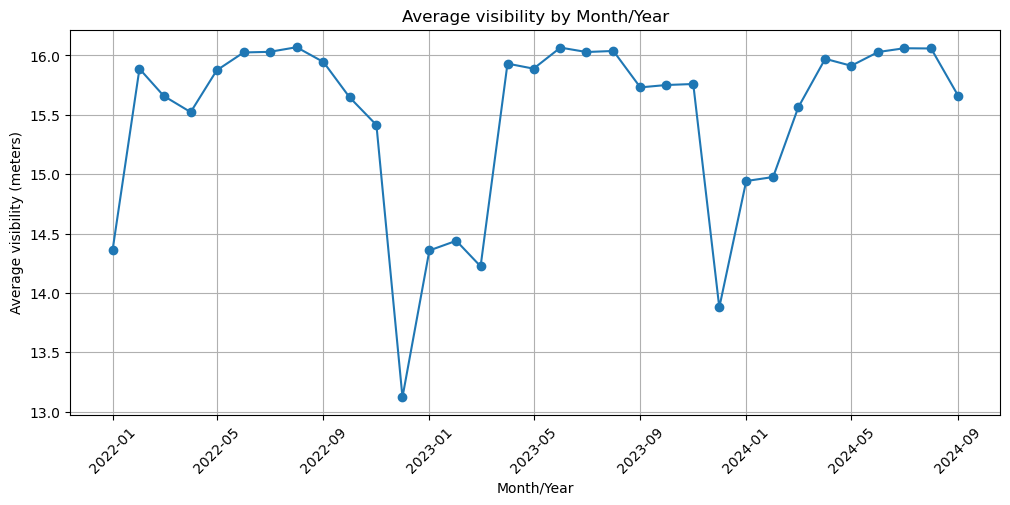

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_weather["Month_Year"], monthly_weather["visibility"], marker="o")

plt.xlabel("Month/Year")
plt.ylabel("Average visibility (meters)")
plt.title("Average visibility by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Monthly precipitation

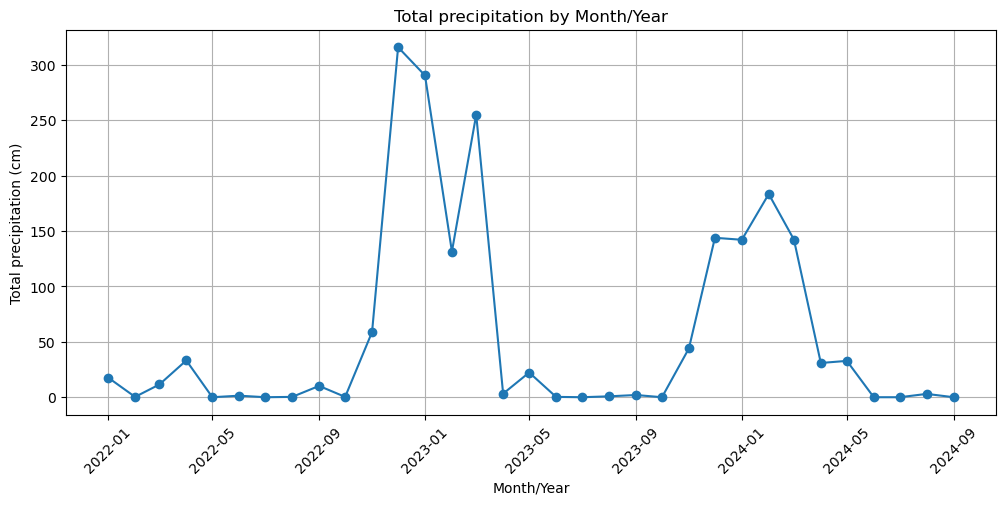

In [14]:
# we should probably do total precipitation here

monthly_precip = NOAA_train_df.groupby("Month_Year")["precipitation"].sum().reset_index()
monthly_precip["Month_Year"] = monthly_precip["Month_Year"].dt.to_timestamp()


plt.figure(figsize=(12, 5))
plt.plot(monthly_precip["Month_Year"], monthly_precip["precipitation"],marker="o")
plt.xlabel("Month/Year")
plt.ylabel("Total precipitation (cm)")
plt.title("Total precipitation by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

Monthly Relative Humidity

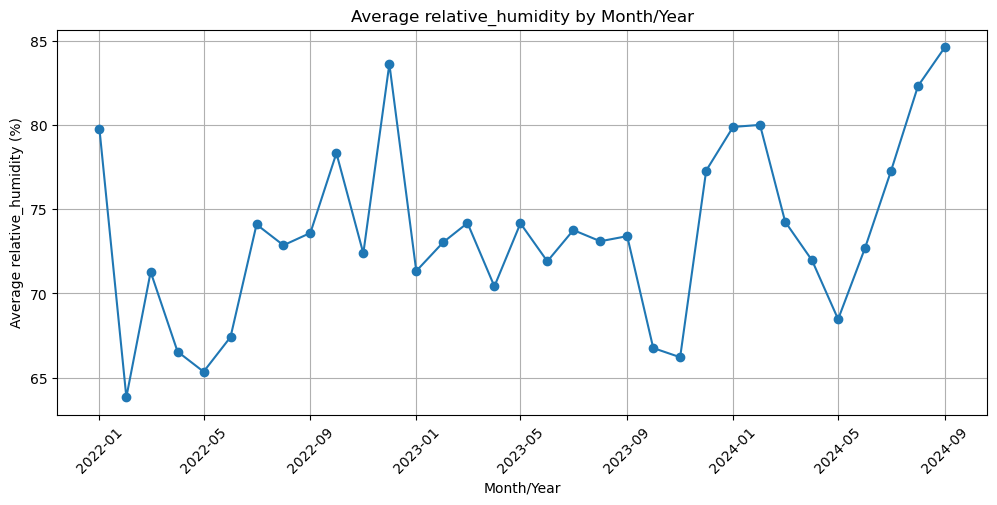

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_weather["Month_Year"], monthly_weather["relative_humidity"], marker="o")

plt.xlabel("Month/Year")
plt.ylabel("Average relative_humidity (%)")
plt.title("Average relative_humidity by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Correlation Matrix**

In [16]:
corr = NOAA_train_df[feature_cols].corr()

display(corr)

,LATITUDE,LONGITUDE,ELEVATION,temperature,dew_point_temperature,wind_direction,wind_speed,precipitation,relative_humidity,visibility,sea_level_pressure,station_level_pressure,ceiling_height,altimeter
LATITUDE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LONGITUDE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ELEVATION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature,NaN,NaN,NaN,1.000000,0.601902,-0.088892,0.276490,-0.089076,-0.508814,0.147676,-0.328281,-0.300977,0.146980,-0.303689
dew_point_temperature,NaN,NaN,NaN,0.601902,1.000000,-0.101169,0.106146,0.025792,0.366324,-0.053954,-0.425562,-0.397065,-0.110392,-0.404798
wind_direction,NaN,NaN,NaN,-0.088892,-0.101169,1.000000,-0.338002,-0.060398,0.005316,0.035695,0.127637,0.130034,0.080569,0.137399
wind_speed,NaN,NaN,NaN,0.276490,0.106146,-0.338002,1.000000,0.081719,-0.226240,-0.004224,-0.301124,-0.302622,0.039256,-0.307128
precipitation,NaN,NaN,NaN,-0.089076,0.025792,-0.060398,0.081719,1.000000,0.148740,-0.491480,-0.181112,-0.205705,-0.201253,-0.205679
relative_humidity,NaN,NaN,NaN,-0.508814,0.366324,0.005316,-0.226240,0.148740,1.000000,-0.264095,-0.083775,-0.081696,-0.303639,-0.086586
visibility,NaN,NaN,NaN,0.147676,-0.053954,0.035695,-0.004224,-0.491480,-0.264095,1.000000,0.072539,0.077396,0.286403,0.088019


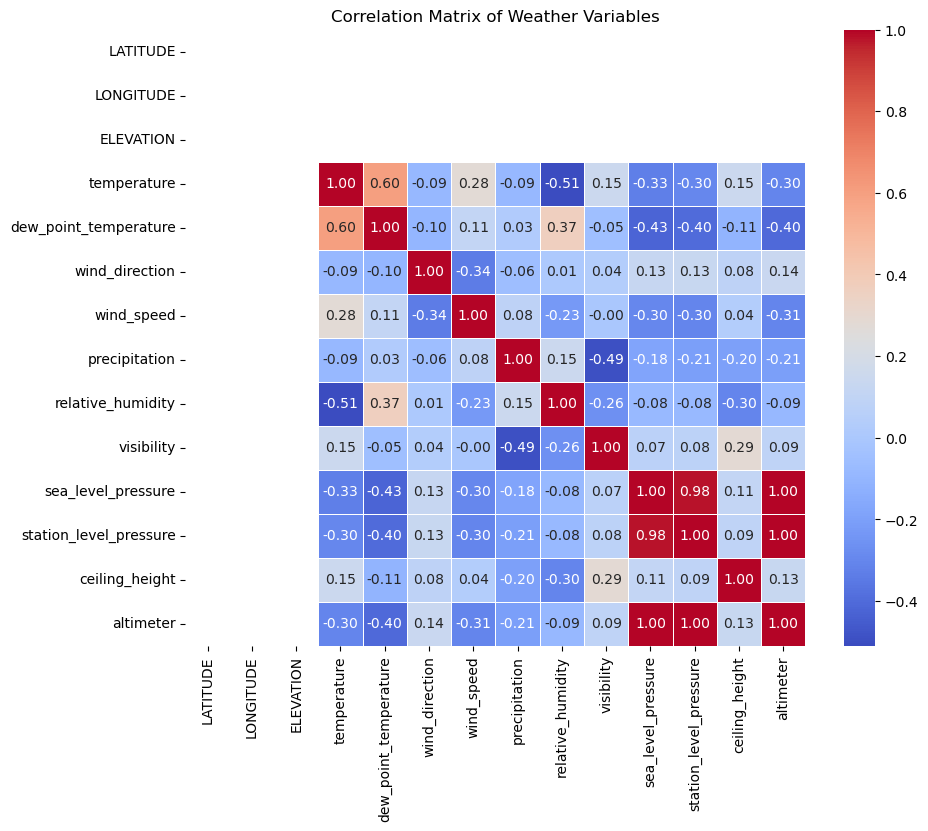

In [17]:
# Plot correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Weather Variables")
plt.show()